# 03 — CDL Corn Mask + HLS NDVI (fixed)

**Key fixes over original:**
- `reproject_match(ndvi, resampling=Resampling.nearest)` replaces `scipy.ndimage.zoom` — CDL mask is reprojected to the exact pixel grid and CRS of each HLS tile before masking
- Main processing loop added (was missing entirely)
- Checkpoint path unified (`ndvi_long.csv` written by loop, read by reshape cell)
- `B8A` → `B05` fallback for L30 tiles
- Cloud-cover filter raised to 40% as fallback when <2 tiles found

**Output:** `data/raw/ndvi_by_state_date.csv`

In [1]:
# ── INSTALL ────────────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ['earthaccess', 'rioxarray', 'pystac-client',
            'planetary-computer', 'rasterio', 'requests']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('Packages OK')

Packages OK


In [2]:
# ── IMPORTS ────────────────────────────────────────────────────────────────────
import os, gc, warnings
import numpy as np
import pandas as pd
import rioxarray as rxr
import earthaccess
from rasterio.enums import Resampling
from pathlib import Path
from datetime import date, timedelta
from pystac_client import Client

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [3]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
STATE_BBOX = {
    'Iowa':      [-96.64, 40.37, -90.14, 43.50],
    'Colorado':  [-109.06, 36.99, -102.04, 41.00],
    'Wisconsin': [-92.89, 42.49, -86.25, 47.08],
    'Missouri':  [-95.77, 35.99, -89.10, 40.61],
    'Nebraska':  [-104.05, 39.99, -95.31, 43.00],
}

FORECAST_DATES = {
    'aug1':  '08-01',
    'sep1':  '09-01',
    'oct1':  '10-01',
    'final': '11-01',
}

YEARS           = range(2015, 2025)
WINDOW_DAYS     = 7          # ±7 days around each forecast date
MAX_TILES_HLS   = 6          # max HLS tiles to composite per window
CLOUD_MAX       = 20         # primary cloud % threshold
CLOUD_MAX_FALLBACK = 40      # fallback if <2 tiles found at primary threshold
CDL_CORN_VAL    = 1          # CDL class value for corn
CDL_MASK_DIR    = Path('/home/sagemaker-user/cdl_masks')  # pre-clipped local TIFs
CDL_MASK_YEAR   = 2022       # static mask year (all target years use this)

HLS_COLLECTION  = 'HLSS30.v2.0'
HLS_STAC_URL    = 'https://cmr.earthdata.nasa.gov/stac/LPCLOUD'

OUT_DIR    = Path('data/raw')
OUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT = OUT_DIR / 'ndvi_long.csv'

print('Config OK')
print(f'States : {list(STATE_BBOX.keys())}')
print(f'Years  : {list(YEARS)}')

Config OK
States : ['Iowa', 'Colorado', 'Wisconsin', 'Missouri', 'Nebraska']
Years  : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [4]:
# ── NASA EARTHDATA AUTH ────────────────────────────────────────────────────────
try:
    earthaccess.login(strategy='netrc')
    print('Earthdata: OK (netrc)')
except Exception:
    print('Launching interactive Earthdata login...')
    earthaccess.login(strategy='interactive')

fs          = earthaccess.get_fsspec_https_session()
hls_catalog = Client.open(HLS_STAC_URL, headers={})
print('HLS STAC: connected')

Launching interactive Earthdata login...


Enter your Earthdata Login username:  havenj
Enter your Earthdata password:  ········


HLS STAC: connected


In [5]:
# ── CDL CORN MASK ─────────────────────────────────────────────────────────────
# Loads pre-clipped CDL TIF from local disk.
# Returns a boolean xarray DataArray (True = corn pixel) in its native CRS.
# The CRS mismatch vs. HLS tiles is resolved in compute_ndvi() via reproject_match.

_cdl_cache: dict = {}

def fetch_cdl_corn_mask(state_name: str):
    if state_name in _cdl_cache:
        return _cdl_cache[state_name]

    local_path = CDL_MASK_DIR / f'{state_name}_{CDL_MASK_YEAR}.tif'
    if not local_path.exists():
        print(f'  WARNING: {local_path} not found — no mask for {state_name}.')
        _cdl_cache[state_name] = None
        return None

    try:
        cdl  = rxr.open_rasterio(local_path, masked=True).squeeze()
        mask = (cdl == CDL_CORN_VAL).astype(np.uint8)
        n_corn = int(mask.sum().values)
        print(f'  CDL {CDL_MASK_YEAR} loaded for {state_name}: {n_corn:,} corn pixels '
              f'(CRS: {mask.rio.crs})')
        _cdl_cache[state_name] = mask
        return mask
    except Exception as e:
        print(f'  WARNING: CDL read failed for {state_name}: {e}')
        _cdl_cache[state_name] = None
        return None

print('CDL function defined')

CDL function defined


In [6]:
# ── HLS SEARCH ────────────────────────────────────────────────────────────────

def search_hls_tiles(bbox: list, date_str: str, year: int, cloud_max: int) -> list:
    """Search HLS STAC for tiles covering bbox within ±WINDOW_DAYS of date_str."""
    target = date(year, int(date_str[:2]), int(date_str[3:]))
    start  = (target - timedelta(days=WINDOW_DAYS)).isoformat()
    end    = (target + timedelta(days=WINDOW_DAYS)).isoformat()
    try:
        results = hls_catalog.search(
            collections=[HLS_COLLECTION],
            bbox=bbox,
            datetime=f'{start}/{end}',
            query={'eo:cloud_cover': {'lt': cloud_max}},
            max_items=50,
        )
        return list(results.items())
    except Exception as e:
        print(f'    HLS search error: {e}')
        return []

print('HLS search function defined')

HLS search function defined


In [7]:
# ── NDVI COMPUTATION ──────────────────────────────────────────────────────────
# KEY FIX: corn_mask is reprojected onto the HLS tile's exact pixel grid
# via reproject_match before any masking is applied, eliminating the CRS
# mismatch and pixel-index drift that caused masking to silently fail.

def _open_band(item, band_key: str, fs_session):
    """Open an HLS band as a float xarray, scaled to [0, 1]."""
    with fs_session.open(item.assets[band_key].href) as f:
        arr = rxr.open_rasterio(f, masked=True).squeeze()
    arr = arr.where(arr != -9999).astype(float) / 10000.0
    return arr


def compute_ndvi(item, fs_session, corn_mask) -> tuple[float, int]:
    """
    Compute mean corn-masked NDVI for one HLS tile.

    Returns
    -------
    (ndvi_mean, n_corn_pixels)
        ndvi_mean      : float, NaN if computation fails
        n_corn_pixels  : int, -1 if no mask applied
    """
    try:
        # Determine whether tile is S30 (B8A/B04) or L30 (B05/B04)
        if 'B8A' in item.assets:
            nir = _open_band(item, 'B8A', fs_session)
        elif 'B05' in item.assets:
            nir = _open_band(item, 'B05', fs_session)
        else:
            print('    No NIR band found — skipping tile')
            return np.nan, 0

        red  = _open_band(item, 'B04', fs_session)
        ndvi = (nir - red) / (nir + red + 1e-10)
        ndvi = ndvi.where((ndvi >= -1) & (ndvi <= 1))

        corn_px = -1
        if corn_mask is not None:
            # Reproject CDL mask to HLS tile CRS + pixel grid — the core fix.
            # order=0 (nearest-neighbor) preserves the binary class boundary.
            mask_aligned = corn_mask.rio.reproject_match(
                ndvi, resampling=Resampling.nearest
            )
            ndvi    = ndvi.where(mask_aligned == 1)
            corn_px = int((mask_aligned == 1).sum().values)

        valid = ndvi.values[np.isfinite(ndvi.values)]
        mean_val = float(np.nanmean(valid)) if valid.size > 0 else np.nan

        del nir, red, ndvi
        gc.collect()
        return mean_val, corn_px

    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f'    tile error: {e}')
        return np.nan, 0


print('NDVI function defined')

NDVI function defined


In [8]:
# ── LOAD CHECKPOINT ───────────────────────────────────────────────────────────
if CHECKPOINT.exists():
    existing = pd.read_csv(CHECKPOINT)
    records  = existing.to_dict('records')
    done     = set(zip(
        existing['state'],
        existing['year'].astype(int),
        existing['forecast_date'],
    ))
    print(f'Resuming — {len(records)} records saved, {len(done)} combos done')
else:
    records = []
    done    = set()
    print('Starting fresh')

Starting fresh


In [9]:
# ── MAIN LOOP ─────────────────────────────────────────────────────────────────
# Iterates states × years × forecast dates.
# Checkpoints after every state so re-runs skip completed work.

total_combos = len(STATE_BBOX) * len(list(YEARS)) * len(FORECAST_DATES)
print(f'Total combos to process: {total_combos} ({len(done)} already done)\n')

for state, bbox in STATE_BBOX.items():
    print(f'\n══ {state} ══')
    corn_mask = fetch_cdl_corn_mask(state)

    for year in YEARS:
        for fd_key, fd_val in FORECAST_DATES.items():
            if (state, year, fd_key) in done:
                continue

            print(f'  {state} {year} {fd_key} ...', end=' ', flush=True)

            # Search with primary cloud threshold; fall back if too few tiles
            tiles = search_hls_tiles(bbox, fd_val, year, CLOUD_MAX)
            if len(tiles) < 2:
                tiles = search_hls_tiles(bbox, fd_val, year, CLOUD_MAX_FALLBACK)

            ndvi_vals  = []
            tiles_used = 0
            for tile in tiles[:MAX_TILES_HLS]:
                val, _ = compute_ndvi(tile, fs, corn_mask)
                if not np.isnan(val):
                    ndvi_vals.append(val)
                    tiles_used += 1

            ndvi_mean = float(np.nanmean(ndvi_vals)) if ndvi_vals else np.nan
            print(f'{ndvi_mean:.4f} ({tiles_used}/{len(tiles)} tiles used)')

            records.append({
                'state':         state,
                'year':          year,
                'forecast_date': fd_key,
                'ndvi_mean':     ndvi_mean,
                'tiles_found':   len(tiles),
                'tiles_used':    tiles_used,
                'masked':        corn_mask is not None,
            })
            done.add((state, year, fd_key))

    # Checkpoint after each state
    pd.DataFrame(records).to_csv(CHECKPOINT, index=False)
    print(f'  → Checkpoint saved ({len(records)} records total)')

print('\nLoop complete.')

Total combos to process: 200 (0 already done)


══ Iowa ══
  CDL 2022 loaded for Iowa: 71,086,956 corn pixels (CRS: EPSG:5070)
  Iowa 2015 aug1 ... nan (0/0 tiles used)
  Iowa 2015 sep1 ... nan (0/0 tiles used)
  Iowa 2015 oct1 ... nan (0/0 tiles used)
  Iowa 2015 final ... nan (0/0 tiles used)
  Iowa 2016 aug1 ... 0.8421 (2/2 tiles used)
  Iowa 2016 sep1 ... nan (0/0 tiles used)
  Iowa 2016 oct1 ... 0.4221 (6/41 tiles used)
  Iowa 2016 final ... 0.3122 (6/28 tiles used)
  Iowa 2017 aug1 ... 0.8518 (6/25 tiles used)
  Iowa 2017 sep1 ... 0.7948 (6/11 tiles used)
  Iowa 2017 oct1 ... 0.5026 (6/14 tiles used)
  Iowa 2017 final ... 0.3091 (6/9 tiles used)
  Iowa 2018 aug1 ... 0.8381 (6/49 tiles used)
  Iowa 2018 sep1 ... 0.7312 (6/19 tiles used)
  Iowa 2018 oct1 ... 0.4416 (6/21 tiles used)
  Iowa 2018 final ... 0.3103 (6/30 tiles used)
  Iowa 2019 aug1 ... 0.7946 (6/50 tiles used)
  Iowa 2019 sep1 ... 0.8734 (6/50 tiles used)
  Iowa 2019 oct1 ... 0.6855 (6/50 tiles used)
  Iowa 2019 final

In [10]:
# ── RESHAPE TO WIDE + SAVE FINAL OUTPUT ───────────────────────────────────────
long_df = pd.read_csv(CHECKPOINT)

print(f'Long shape   : {long_df.shape}')
print(f'Masked rows  : {long_df["masked"].sum()} / {len(long_df)}')
print(f'Missing NDVI : {long_df["ndvi_mean"].isna().sum()} / {len(long_df)}')
print()

wide_df = (
    long_df
    .pivot_table(index=['state', 'year'], columns='forecast_date', values='ndvi_mean')
    .reset_index()
)
wide_df.columns.name = None
wide_df = wide_df.rename(columns={
    'aug1':  'ndvi_aug1',
    'sep1':  'ndvi_sep1',
    'oct1':  'ndvi_oct1',
    'final': 'ndvi_final',
})

# Interpolate isolated missing windows; leave fully empty rows as NaN
ndvi_cols = ['ndvi_aug1', 'ndvi_sep1', 'ndvi_oct1', 'ndvi_final']
wide_df[ndvi_cols] = wide_df[ndvi_cols].interpolate(axis=1, limit_direction='both')

out_path = OUT_DIR / 'ndvi_by_state_date.csv'
wide_df.to_csv(out_path, index=False)
print(f'Saved: {out_path} ({len(wide_df)} rows)')
print(f'Columns: {list(wide_df.columns)}')
wide_df.head(10)

Long shape   : (200, 7)
Masked rows  : 200 / 200
Missing NDVI : 22 / 200

Saved: data/raw/ndvi_by_state_date.csv (45 rows)
Columns: ['state', 'year', 'ndvi_aug1', 'ndvi_final', 'ndvi_oct1', 'ndvi_sep1']


,state,year,ndvi_aug1,ndvi_final,ndvi_oct1,ndvi_sep1
0,Colorado,2016,0.314774,0.312406,0.272449,0.662685
1,Colorado,2017,0.470774,0.409948,0.394210,0.443056
2,Colorado,2018,0.617053,0.298484,0.402170,0.424081
3,Colorado,2019,0.552402,0.290052,0.384757,0.383130
4,Colorado,2020,0.700281,0.078682,0.397308,0.573319
5,Colorado,2021,0.384108,0.316767,0.471250,0.651742
6,Colorado,2022,0.395423,0.276528,0.473334,0.463699
7,Colorado,2023,0.292777,0.286022,0.503966,0.528917
8,Colorado,2024,0.593263,0.268619,0.508185,0.639359
9,Iowa,2016,0.842079,0.312219,0.422135,0.632107


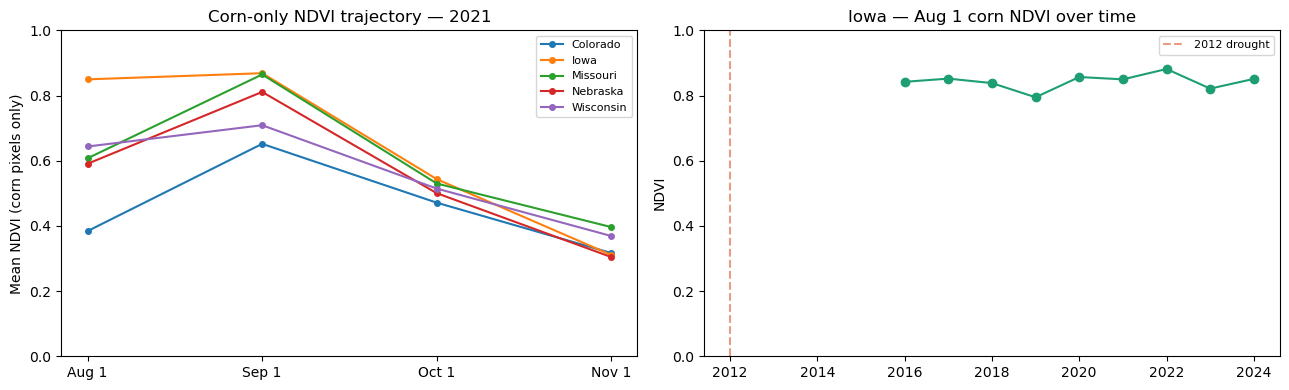


→ Next: 04_merge_features.ipynb


In [11]:
# ── SANITY CHECK ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sample_year = 2021
subset = wide_df[wide_df['year'] == sample_year]
for _, row in subset.iterrows():
    axes[0].plot(
        ['Aug 1', 'Sep 1', 'Oct 1', 'Nov 1'],
        [row['ndvi_aug1'], row['ndvi_sep1'], row['ndvi_oct1'], row['ndvi_final']],
        marker='o', markersize=4, label=row['state'],
    )
axes[0].set_title(f'Corn-only NDVI trajectory — {sample_year}')
axes[0].set_ylabel('Mean NDVI (corn pixels only)')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

iowa = wide_df[wide_df['state'] == 'Iowa'].sort_values('year')
axes[1].plot(iowa['year'], iowa['ndvi_aug1'], marker='o', color='#1D9E75')
axes[1].axvline(2012, color='#D85A30', linestyle='--', alpha=0.6, label='2012 drought')
axes[1].set_title('Iowa — Aug 1 corn NDVI over time')
axes[1].set_ylabel('NDVI')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'ndvi_sanity_check.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n→ Next: 04_merge_features.ipynb')

## Troubleshooting

| Symptom | Fix |
|---|---|
| Kernel dies mid-loop | Re-run from the Load Checkpoint cell — skips all completed combos |
| All NDVI NaN for a state/year | Raise `CLOUD_MAX_FALLBACK` from 40 → 60 |
| `KeyError: 'B8A'` and `KeyError: 'B05'` | Tile has non-standard band naming — inspect `item.assets.keys()` |
| CDL shows UNMASKED | `{state}_{CDL_MASK_YEAR}.tif` not found in CDL_MASK_DIR — verify path |
| `401` on HLS search | Re-run earthaccess.login(strategy='interactive') to refresh .netrc |
| `NoDataInBounds` on reproject_match | CDL TIF bbox doesn't overlap HLS tile — check CDL pre-clip extent |
| NDVI suspiciously high (>0.85) for all states | CDL mask not loading (None) — falling back to full-state average |